# Efecto Coriolis Simple
**Alejandro Jaramillo Moreno**<br>
Instituto de Ciencias de la Atmósfera y Cambio Climático<br>
Universidad Nacional Autónoma de México<br>

## Introducción
En el presente cuaderno se usarán las componentes de la aceleración de Coriolis de la forma<br>
$\frac{Du}{Dt}=2\Omega\sin{\phi}v+\frac{uv}{r}\tan{\phi}$,<br>
$\frac{Dv}{Dt}=-2\Omega\sin{\phi}u+\frac{u^2}{r}$,<br>
para resolver el movimiento de un cuerpo.

Se desarrollará la trayectoria de un cuerpo en un plano $XY$ con parámetro de Coriolis $f = 2\Omega\sin{\phi}$ constante.

Se analizará los efectos de la trayectoria si se tienen en cuenta los términos de curvatura, así como en caso de que se ignoren estos efectos.

In [49]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.animation

# Constantes 
pi = np.pi
## Radio medio de la Tierra en m
rad = 6.37e6
## Velocidad angular de rotación de la Tierra en rad s^-1
omega = 7.292e-5

def coriolis_parameter(phi,omega):
    """
    Calculo del parámetro de Coriolis f en función de la latitud phi en radianes.
    """
    return (2.0*omega)*np.sin(phi)

def deg2rad(phi):
    """
    Convierte un ángulo phi en grados a radianes.
    """
    return pi*phi/180.0

def coriolis_fconst(v,tt,f):
    """
    Se resuelve las ecuaciones simplificadas en un plano que no tiene en cuenta la curvatura de la tierra.
    dx/dt = u
    dy/dt = v
    du/dt = f*v
    dv/dt = -f*u
    Se asume que los cambios son pequeños y f es constante.
    """
    x, y, ux, uy = v
    xp = ux
    yp = uy
    uxp = f*uy
    uyp = -f*ux
    return xp, yp, uxp, uyp


def coriolis_fconst_curv(v,tt,phi):
    """
    Se resuelve las ecuaciones simplificadas en un plano que no tiene en cuenta la curvatura de la tierra.
    dx/dt = u
    dy/dt = v
    du/dt = f*v
    dv/dt = -f*u
    Se asume que los cambios son pequeños y f es constante.
    """
    f = coriolis_parameter(deg2rad(phi),omega)
    x, y, ux, uy = v
    xp = ux
    yp = uy
    uxp = f*uy + (ux*uy*np.tan(phi))/rad
    uyp = -f*ux - ux**2/rad
    return xp, yp, uxp, uyp

In [37]:
# Datos del Usuario

# Latitud
ini_lat = 40.0


# Periodo de integración en segundos
time = 1000 

# delta de tiempo
delta_t = 10


# Coordenadas X y Y iniciales (En m. Por defecto (0,0))
x0 = 0
y0 = 0


# Componentes ux y uy de la velocidad (en m/s):
ux0 = 1000
uy0 = 0

In [50]:
f = coriolis_parameter(deg2rad(ini_lat),omega)
tiempos = np.arange(0, time+0.1, delta_t)
f0 = odeint(coriolis_fconst,(x0,y0,ux0,uy0),tiempos,args=(f,))
x,y,ux,uy = f0.T
df = pd.DataFrame({'x':x,'y':y,'ux':ux,'uy':uy,'time':tiempos})
df = df.set_index('time')
print('HEAD')
print(df.head())
print('\nTAIL')
print(df.tail())

HEAD
                 x          y           ux        uy
time                                                
0.0       0.000000   0.000000  1000.000000  0.000000
10.0   9999.998535  -4.687207   999.999561 -0.937441
20.0  19999.988283 -18.748824   999.998242 -1.874882
30.0  29999.960454 -42.184837   999.996045 -2.812321
40.0  39999.906262 -74.995228   999.992970 -3.749757

TAIL
                    x             y          ux         uy
time                                                      
960.0   958704.689026 -43168.155523  995.953238 -89.872951
970.0   968663.798755 -44071.553148  995.868550 -90.806560
980.0   978622.057205 -44984.286455  995.782987 -91.740088
990.0   988579.455629 -45906.354644  995.696548 -92.673536
1000.0  998535.985440 -46837.756914  995.609235 -93.606902


In [52]:
f1 = odeint(coriolis_fconst_curv,(x0,y0,ux0,uy0),tiempos,args=(ini_lat,))
x,y,ux,uy = f1.T
df_curv = pd.DataFrame({'x':x,'y':y,'ux':ux,'uy':uy,'time':tiempos})
df_curv = df_curv.set_index('time')
print('HEAD')
print(df_curv.head())
print('\nTAIL')
print(df_curv.tail())

HEAD
                 x           y           ux         uy
time                                                  
0.0       0.000000    0.000000  1000.000000   0.000000
10.0  10000.003412  -12.536504  1000.001024  -2.507302
20.0  20000.027294  -50.146059  1000.004094  -5.014611
30.0  30000.092117 -112.828789  1000.009212  -7.521938
40.0  40000.218353 -200.584903  1000.016377 -10.029290

TAIL
                   x              y           ux          uy
time                                                        
960.0   9.630416e+05 -115833.697755  1009.553706 -241.943667
970.0   9.731382e+05 -118265.867791  1009.756394 -244.490478
980.0   9.832368e+05 -120723.510130  1009.961292 -247.038126
990.0   9.933374e+05 -123206.633174  1010.168405 -249.586620
1000.0  1.003440e+06 -125715.245433  1010.377735 -252.135970


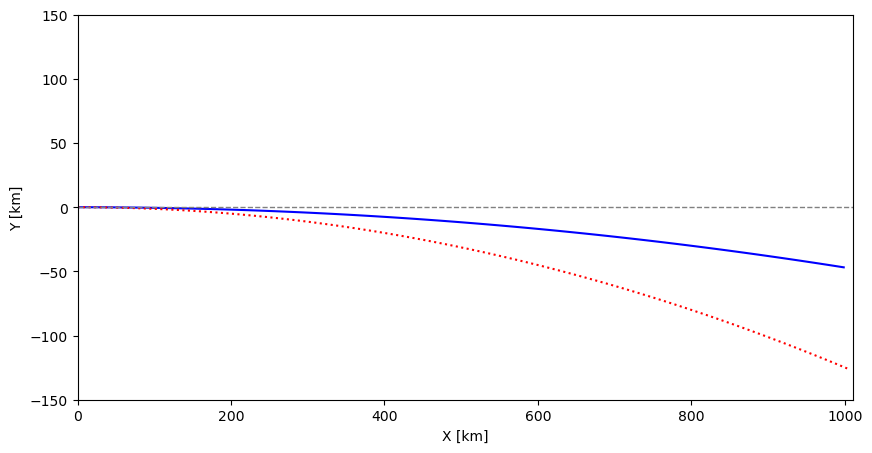

In [56]:
fig,ax = plt.subplots(figsize=(10,5))
ax.plot(df['x'].values/1000,df['y'].values/1000,lw=1.5, color='blue')
ax.plot(df_curv['x'].values/1000,df_curv['y'].values/1000,lw=1.5,ls=':', color='red')
ax.axhline(0,ls='--',color='grey',lw=1.0)
ax.set_xlim(0,1010)
ax.set_ylim(-150,150)
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
plt.show()